In [2]:
import pandas as pd
import pylab as plt
import numpy as np
import glob

In [3]:
df = pd.read_csv('output/Sept30_Storm_filtered.csv', parse_dates=['start_time', 'end_time'], index_col=0)
df

,start_time,end_time,Bx,By,Bz,score,file_name,B,cone_angle,clock_angle,label,aci_file,ead_file
index,,,,,,,,,,,,,
0,2025-09-27 01:21:19,2025-09-27 01:22:37,-1.936180,-4.495037,0.769296,0.663395,TracersDispersionEvent_TS2_2025-09-27T01:21:19...,4.954389,113.004350,279.711705,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20250927_...,data/Sept30_Storm/ead/ts2_def_ead_20250927_v0....
5,2025-09-28 01:30:13,2025-09-28 01:31:32,-2.991730,4.040490,-4.695540,0.859231,TracersDispersionEvent_TS2_2025-09-28T01:30:13...,6.879252,115.778408,139.288158,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20250928_...,data/Sept30_Storm/ead/ts2_def_ead_20250928_v0....
20,2025-09-28 16:02:20,2025-09-28 16:03:41,-1.384180,-10.228882,-3.035928,0.573218,TracersDispersionEvent_TS2_2025-09-28T16:02:20...,10.759314,97.391556,253.469133,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20250928_...,data/Sept30_Storm/ead/ts2_def_ead_20250928_v0....
32,2025-09-30 11:28:56,2025-09-30 11:30:19,-8.338225,7.268442,-5.527518,0.688864,TracersDispersionEvent_TS2_2025-09-30T11:28:56...,12.365666,132.400167,127.252329,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20250930_...,data/Sept30_Storm/ead/ts2_def_ead_20250930_v0....
34,2025-10-01 16:29:31,2025-10-01 16:30:54,-6.210000,5.120000,-3.450000,0.664833,TracersDispersionEvent_TS2_2025-10-01T16:29:31...,8.756769,135.167075,123.973199,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20251001_...,data/Sept30_Storm/ead/ts2_def_ead_20251001_v0....
41,2025-10-02 11:47:46,2025-10-02 11:48:55,-6.210000,5.120000,-3.450000,0.768815,TracersDispersionEvent_TS2_2025-10-02T11:47:46...,8.756769,135.167075,123.973199,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20251002_...,data/Sept30_Storm/ead/ts2_def_ead_20251002_v0....
42,2025-10-02 13:24:18,2025-10-02 13:25:22,-6.210000,5.120000,-3.450000,0.516902,TracersDispersionEvent_TS2_2025-10-02T13:24:18...,8.756769,135.167075,123.973199,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20251002_...,data/Sept30_Storm/ead/ts2_def_ead_20251002_v0....
61,2025-10-03 23:09:40,2025-10-03 23:10:53,-6.210000,5.120000,-3.450000,0.250695,TracersDispersionEvent_TS2_2025-10-03T23:09:40...,8.756769,135.167075,123.973199,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20251003_...,data/Sept30_Storm/ead/ts2_def_ead_20251003_v0....
64,2025-10-04 05:36:14,2025-10-04 05:37:22,-6.210000,5.120000,-3.450000,0.724066,TracersDispersionEvent_TS2_2025-10-04T05:36:14...,8.756769,135.167075,123.973199,ByDominant,data/Sept30_Storm/aci/ts2_l2_aci_ipd_20251004_...,data/Sept30_Storm/ead/ts2_def_ead_20251004_v0....


In [4]:
recon_rates = {}

for i in range(len(df)):
    recon_rates[i] = pd.read_csv(f'output/recon_event{i}.csv')

In [5]:
from cdasws import CdasWs
start_time = "2025-09-27T00:00:00"
end_time = "2025-10-8T00:00:00"
variables = [
   "BX_GSE",
   "BY_GSM",
   "BZ_GSM",
   "Pressure",
   "SYM_H",
]
cdas = CdasWs()
status, data_xarray = cdas.get_data("OMNI_HRO_1MIN", variables, start_time, end_time)
omni_epoch = data_xarray['Epoch']
omni_Bx = data_xarray['BX_GSE']
omni_By = data_xarray['BY_GSM']
omni_Bz = data_xarray['BZ_GSM']
omni_dynpres = data_xarray['Pressure']
symh = data_xarray['SYM_H']

fill_value = 9999
omni_Bx[omni_Bx>fill_value] = np.nan
omni_By[omni_By>fill_value] = np.nan
omni_Bz[omni_Bz>fill_value] = np.nan

fill_value = 99
omni_dynpres[omni_dynpres>=fill_value] = np.nan

/home/dedasilv/micromamba/envs/tracers-dispersion-detection/lib/python3.11/site-packages/spacepy/time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()


In [6]:
cpcp_files = glob.glob('data/daSilva-cpcp/*.txt')
dfs_tmp = []

for cpcp_file in cpcp_files:
    df_cpcp = pd.read_csv(cpcp_file, sep='\t')
    df_cpcp.columns = df_cpcp.columns.str.strip()
    df_cpcp['DATE'] = pd.to_datetime(df_cpcp['DATE'])
    dfs_tmp.append(df_cpcp)

df_cpcp = pd.concat(dfs_tmp)
df_cpcp = df_cpcp.sort_values('DATE')
df_cpcp = df_cpcp[(df_cpcp.DATE > omni_epoch[0]) & (df_cpcp.DATE < omni_epoch[-1])]

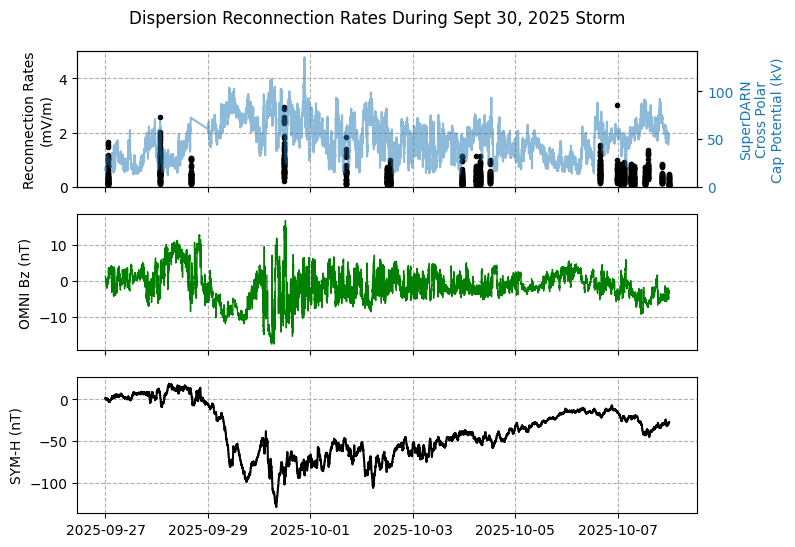

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

for i in range(len(df)):
    xs = [df.iloc[i].start_time] * len(recon_rates[i])
    ys = recon_rates[i].recon_rate
    axes[0].plot(xs, ys, 'k.')

axes[0].set_ylim(0, 5)
axes[0].set_ylabel('Reconnection Rates\n(mV/m)')
axes[0].grid(linestyle='dashed')

ax = axes[0].twinx()
ax.plot(df_cpcp.DATE, df_cpcp.CPCP / 1000, alpha=0.5)
ax.set_ylabel('SuperDARN\nCross Polar\nCap Potential (kV)', color='C0')
ax.tick_params(axis='y', labelcolor='C0')
ax.set_ylim(0, max(ax.get_ylim()))
#axes[0].set_zorder(ax.get_zorder() + 1)

axes[1].plot(omni_epoch, omni_Bz, color='g', linewidth=1)
axes[1].grid(linestyle='dashed')
axes[1].set_ylabel('OMNI Bz (nT)')

axes[2].grid(linestyle='dashed')
axes[2].plot(omni_epoch, symh, color='k')
axes[2].set_ylabel('SYM-H (nT)')

fig.suptitle('Dispersion Reconnection Rates During Sept 30, 2025 Storm', y=0.95)
fig.savefig('plots/recon_during_storm.png', dpi=300, bbox_inches='tight')

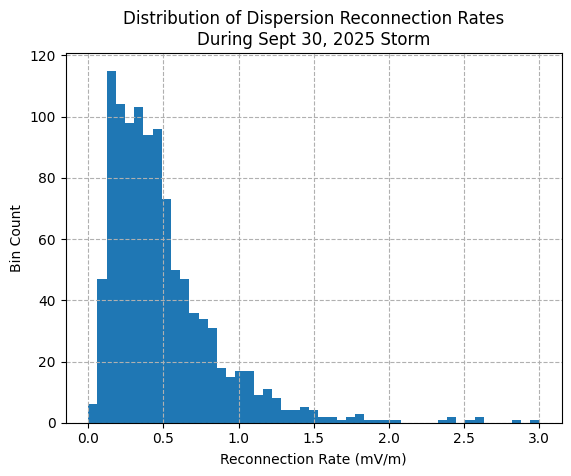

In [8]:
xs = np.concatenate(list([df.recon_rate for df in recon_rates.values()]))
bins = np.linspace(0, 3, 50)
plt.hist(xs, bins=bins)
plt.ylabel('Bin Count')
plt.xlabel('Reconnection Rate (mV/m)')
plt.grid(linestyle='dashed')
plt.title('Distribution of Dispersion Reconnection Rates\nDuring Sept 30, 2025 Storm')
plt.savefig('plots/dist_of_recon_rates.png', dpi=300)
None

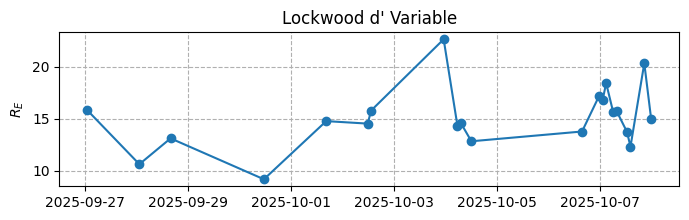

In [9]:
def get_d(i):
    with open(f'output/dprime_{i}.txt', 'r') as fh:
        d = float(fh.read())
       # print(f'd = {d:.2f}')
        return d

ts = df.start_time.values
ds = [get_d(i) for i in range(len(df))]
plt.figure(figsize=(8, 2))
plt.plot(ts, ds, 'o-')
plt.ylabel('$R_E$')
plt.title('Lockwood d\' Variable')
plt.grid(linestyle='dashed')

None

In [46]:
row.aci_file

'data/Sept30_Storm/aci/ts2_l2_aci_ipd_20250927_v1.0.0.cdf'

In [54]:
from spacepy import pycdf

cdf = pycdf.CDF('data/Sept30_Storm/ace/ts2_l2_ace_def_20250927_v1.1.0.cdf')
ace_flux = cdf[f"ts2_l2_ace_def"][:]
ace_spect = ace_flux.sum(axis=-1)
ace_energies = cdf[f"ts2_l2_ace_energy"][:]
ace_time = cdf["Epoch"][:]
cdf.close()


d = 15.79
Bs at satellite 44699.46130975912 nT


/tmp/ipykernel_1975/189830787.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(new_xticklabels)


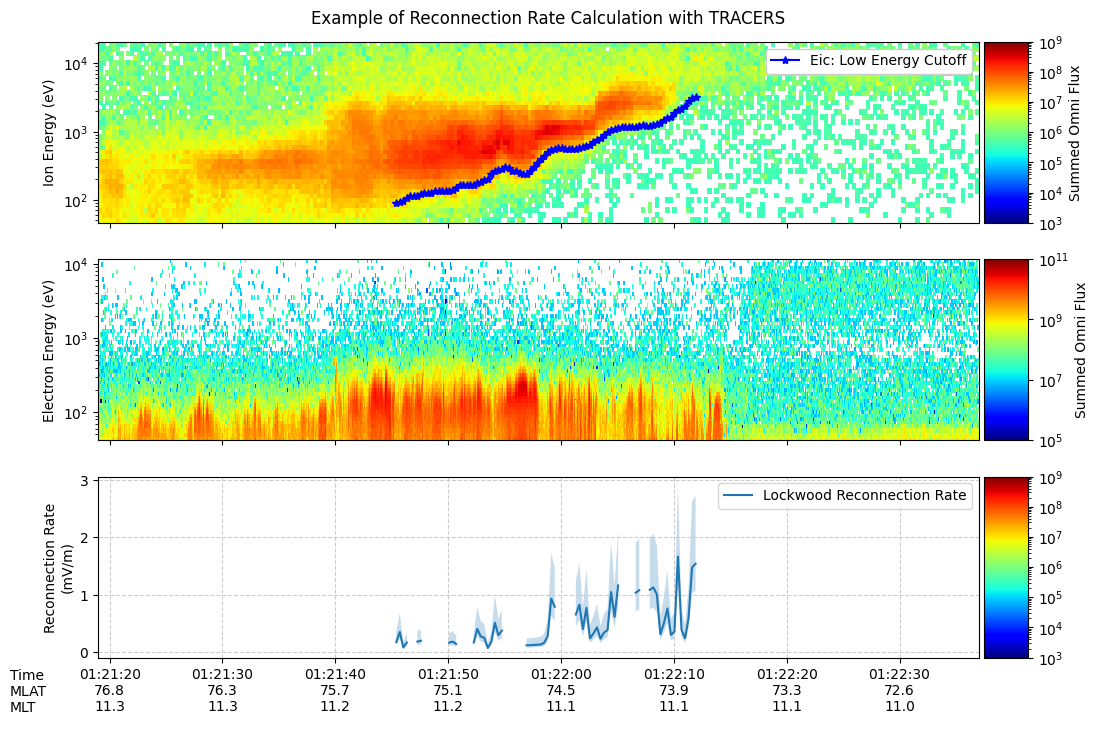

In [77]:
import lib_dasilva2026
from datetime import timedelta
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.dates import num2date
import importlib
importlib.reload(lib_dasilva2026)

def get_d(i):
    with open(f'output/dprime_{i}.txt', 'r') as fh:
        d = float(fh.read())
        print(f'd = {d:.2f}')
        return d

row = df.iloc[0]
d = get_d(0)


data = lib_dasilva2026.load_data(
    aci_file=row.aci_file,
    ead_file=row.ead_file,
)
subset_data = data.subset(row.start_time, row.end_time)
dispersion_stime = row.start_time
dispersion_etime = row.end_time - timedelta(seconds=25)
dispersion_subset = subset_data.subset(dispersion_stime, dispersion_etime)
Eic = dispersion_subset.find_Eic(Eic_frac=0.1)

recon_rate, err_low, err_high = dispersion_subset.calculate_recon_rate(
    alpha=0,
    d=d,
    Eic_frac=0.1,
    forward=True,
)

# Do plotting -----------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(12, 8))
im = ax1.pcolor(
    subset_data.time,
    subset_data.energies[lib_dasilva2026.CHAN_CUTOFF:],
    subset_data.spect.T[lib_dasilva2026.CHAN_CUTOFF:],
    norm=LogNorm(vmin=lib_dasilva2026.SPECT_VMIN, vmax=lib_dasilva2026.SPECT_VMAX),
    cmap='jet',
)
ax1.plot(dispersion_subset.time, Eic, 'b*-', label='Eic: Low Energy Cutoff')
ax1.set_yscale('log')
ax1.set_ylabel('Ion Energy (eV)')
ax1.legend(loc='upper right', framealpha=1)

mask = (ace_time> row.start_time) & (ace_time < row.end_time)

im_e = ax2.pcolor(
    ace_time[mask],
    ace_energies,
    ace_spect[mask].T,
    norm=LogNorm(vmin=1e5, vmax=1e11),
    cmap='jet',
)
ax2.set_yscale('log')
ax2.set_ylabel('Electron Energy (eV)')

ax3.plot(dispersion_subset.time, recon_rate.value, label='Lockwood Reconnection Rate')
ax3.fill_between(dispersion_subset.time, err_low.value, err_high.value, alpha=0.25)
ax3.set_ylabel('Reconnection Rate\n(mV/m)')
ax3.grid(color='#ccc', linestyle='dashed')
plt.legend()

divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical').set_label(r'Summed Omni Flux')

divider = make_axes_locatable(ax2)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im_e, cax=cax, orientation='vertical').set_label(r'Summed Omni Flux')

divider = make_axes_locatable(ax3)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical')

new_xticklabels = []

for xtick in ax3.get_xticks():
    time = num2date(xtick).replace(tzinfo=None)
    i = np.argmin(np.abs(subset_data.time - time))
    new_xticklabel = (
        time.strftime('%H:%M:%S') + '\n'
        + '%.1f' % subset_data.mlat[i] + '\n'
        + '%.1f' % subset_data.mlt[i] + '\n'
    )
    new_xticklabels.append(new_xticklabel)

ax3.set_xticklabels(new_xticklabels)
ax3.text(-0.10, -0.3, "Time\nMLAT\nMLT", transform=ax3.transAxes)

fig.suptitle('Example of Reconnection Rate Calculation with TRACERS', y=0.92)
fig.savefig('plots/recon_rate_event.png', dpi=300, bbox_inches='tight')